In [1]:
# ============================================
# CELL 1: Imports
# ============================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import cv2
import urllib.request
import tarfile
import time
import shutil

print("Imports done ✅")

Imports done ✅


In [2]:
# ============================================
# CELL 2: Dataset paths (SOTS)
# ============================================
base_path = '/kaggle/input/datasets/balraj98/synthetic-objective-testing-set-sots-reside/outdoor'
hazy_dir = os.path.join(base_path, 'hazy')
clear_dir = os.path.join(base_path, 'clear')

hazy_files = sorted(os.listdir(hazy_dir))
clear_files = sorted(os.listdir(clear_dir))

sample_hazy = hazy_files[0]
image_id = sample_hazy.split('_')[0]
sample_clear = image_id + '.png'

hazy_img = Image.open(os.path.join(hazy_dir, sample_hazy))
clear_img = Image.open(os.path.join(clear_dir, sample_clear))

print(f"Hazy: {len(hazy_files)}, Clear: {len(clear_files)}")

Hazy: 500, Clear: 492


In [3]:
# ============================================
# CELL 3: AOD-Net architecture
# ============================================
class AODNet(nn.Module):
    def __init__(self):
        super(AODNet, self).__init__()
        self.relu = nn.ReLU(inplace=True)
        self.e_conv1 = nn.Conv2d(3, 3, 1, 1, 0)
        self.e_conv2 = nn.Conv2d(3, 3, 3, 1, 1)
        self.e_conv3 = nn.Conv2d(6, 3, 5, 1, 2)
        self.e_conv4 = nn.Conv2d(6, 3, 7, 1, 3)
        self.e_conv5 = nn.Conv2d(12, 3, 3, 1, 1)

    def forward(self, x):
        x1 = self.relu(self.e_conv1(x))
        x2 = self.relu(self.e_conv2(x1))
        cat1 = torch.cat((x1, x2), 1)
        x3 = self.relu(self.e_conv3(cat1))
        cat2 = torch.cat((x2, x3), 1)
        x4 = self.relu(self.e_conv4(cat2))
        cat3 = torch.cat((x1, x2, x3, x4), 1)
        k = self.relu(self.e_conv5(cat3))
        output = k * x - k + 1
        output = self.relu(output)
        return output

print("AODNet defined ✅")

AODNet defined ✅


In [4]:
# ============================================
# CELL 4: Download weights + load model
# ============================================
os.makedirs('/kaggle/working/weights', exist_ok=True)
weight_url = "https://raw.githubusercontent.com/MayankSingal/PyTorch-Image-Dehazing/master/snapshots/dehazer.pth"
weight_path = "/kaggle/working/weights/aod_net.pth"

if not os.path.exists(weight_path):
    urllib.request.urlretrieve(weight_url, weight_path)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AODNet().to(device)
model.load_state_dict(torch.load(weight_path, map_location=device))
model.eval()

print("Model loaded ✅ | device:", device)
print("Params:", sum(p.numel() for p in model.parameters()))

Model loaded ✅ | device: cuda
Params: 1761


In [5]:
# ============================================
# CELL 5: Helper functions
# ============================================
def preprocess_image(img_path, device):
    img = Image.open(img_path).convert('RGB')
    img = np.asarray(img, dtype=np.float32) / 255.0
    img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)
    return img.to(device)

def tensor_to_image(tensor):
    img = tensor.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    return np.clip(img, 0, 1)

def add_synthetic_fog(img_path, beta=1.5, A=0.9):
    img = Image.open(img_path).convert('RGB')
    img_np = np.asarray(img, dtype=np.float32) / 255.0
    t = np.exp(-beta)
    foggy = img_np * t + A * (1 - t)
    foggy = np.clip(foggy, 0, 1)
    return Image.fromarray((foggy * 255).astype(np.uint8))

def get_clear_filename(hazy_filename):
    return hazy_filename.split('_')[0] + '.png'

print("Helpers ready ✅")

Helpers ready ✅


In [6]:
# ============================================
# CELL 6: Full-dataset baseline evaluation (PSNR/SSIM)
# ============================================
results = []
for hazy_file in tqdm(hazy_files):
    clear_file = get_clear_filename(hazy_file)
    clear_path = os.path.join(clear_dir, clear_file)
    if not os.path.exists(clear_path):
        continue

    parts = hazy_file.replace('.jpg', '').split('_')
    beta = float(parts[1]) if len(parts) > 1 else None

    hazy_path = os.path.join(hazy_dir, hazy_file)
    hazy_pil = Image.open(hazy_path).convert('RGB')
    clear_pil = Image.open(clear_path).convert('RGB').resize(hazy_pil.size)

    input_tensor = preprocess_image(hazy_path, device)
    with torch.no_grad():
        output_tensor = model(input_tensor)
    dehazed_np = tensor_to_image(output_tensor)
    clear_np = np.asarray(clear_pil, dtype=np.float32) / 255.0

    p = psnr(clear_np, dehazed_np, data_range=1.0)
    s = ssim(clear_np, dehazed_np, channel_axis=2, data_range=1.0)
    results.append({'hazy_file': hazy_file, 'clear_file': clear_file, 'beta': beta, 'psnr': p, 'ssim': s})

df = pd.DataFrame(results)
os.makedirs('/kaggle/working/results', exist_ok=True)
df.to_csv('/kaggle/working/results/aodnet_baseline_results.csv', index=False)

print(f"Average PSNR: {df['psnr'].mean():.2f} dB | Average SSIM: {df['ssim'].mean():.4f}")

100%|██████████| 500/500 [00:48<00:00, 10.39it/s]

Average PSNR: 19.63 dB | Average SSIM: 0.8946


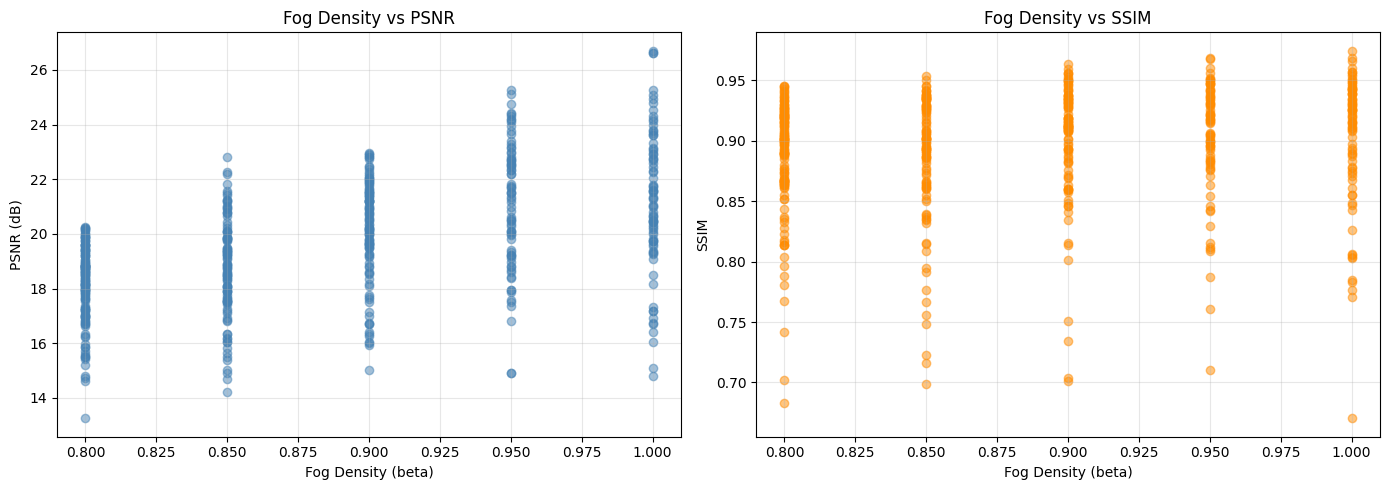

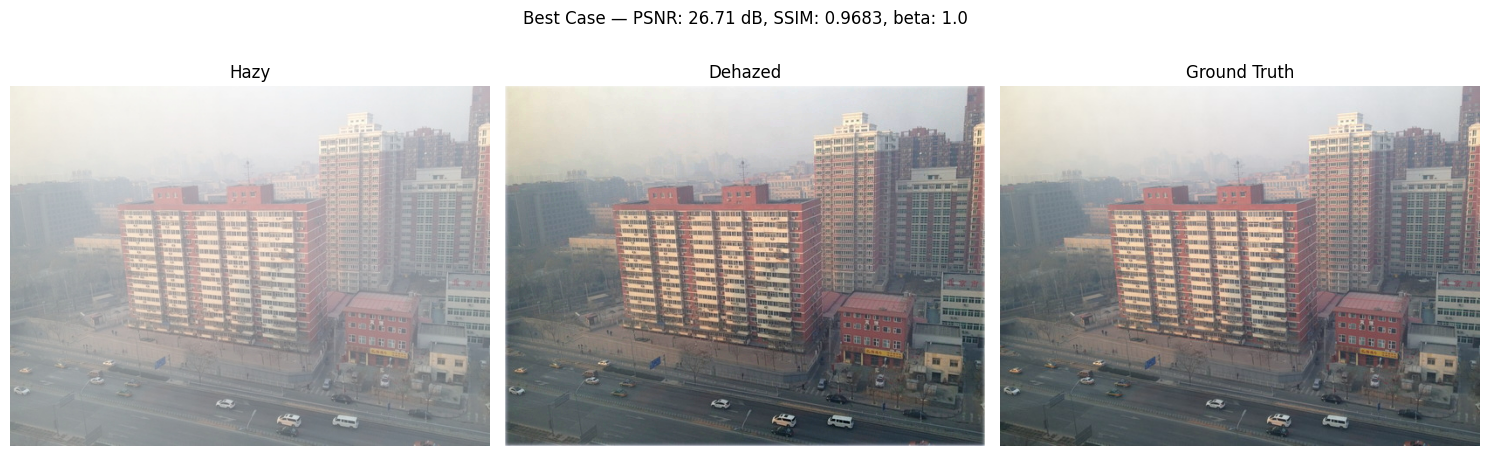

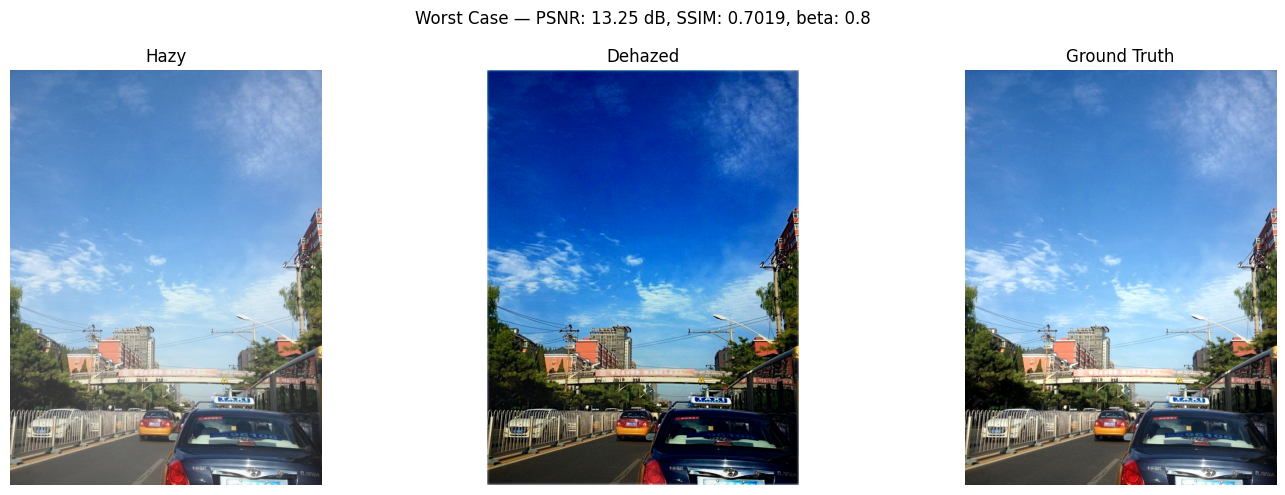

Saved baseline results + plots ✅


In [7]:
# ============================================
# CELL 7: Fog-density correlation plot + best/worst case
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df['beta'], df['psnr'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Fog Density (beta)'); axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('Fog Density vs PSNR'); axes[0].grid(alpha=0.3)
axes[1].scatter(df['beta'], df['ssim'], alpha=0.5, color='darkorange')
axes[1].set_xlabel('Fog Density (beta)'); axes[1].set_ylabel('SSIM')
axes[1].set_title('Fog Density vs SSIM'); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/results/fog_density_correlation.png', dpi=150)
plt.show()

best_case = df.loc[df['psnr'].idxmax()]
worst_case = df.loc[df['psnr'].idxmin()]

def show_case(row, title):
    hazy_pil = Image.open(os.path.join(hazy_dir, row['hazy_file'])).convert('RGB')
    clear_pil = Image.open(os.path.join(clear_dir, row['clear_file'])).convert('RGB').resize(hazy_pil.size)
    input_tensor = preprocess_image(os.path.join(hazy_dir, row['hazy_file']), device)
    with torch.no_grad():
        output_tensor = model(input_tensor)
    dehazed_np = tensor_to_image(output_tensor)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"{title} — PSNR: {row['psnr']:.2f} dB, SSIM: {row['ssim']:.4f}, beta: {row['beta']}")
    axes[0].imshow(hazy_pil); axes[0].set_title('Hazy'); axes[0].axis('off')
    axes[1].imshow(dehazed_np); axes[1].set_title('Dehazed'); axes[1].axis('off')
    axes[2].imshow(clear_pil); axes[2].set_title('Ground Truth'); axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/results/{title.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

show_case(best_case, "Best Case")
show_case(worst_case, "Worst Case")
print("Saved baseline results + plots ✅")

In [8]:
# ============================================
# CELL 8: Install insightface (may restart session)
# ============================================
!pip install insightface onnxruntime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 12.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 86.8 MB/s eta 0:00:00:00:0100:01


In [9]:
# ============================================
# CELL 9: LFW extraction + Face app load (CPU-safe)
# ============================================
lfw_input_folder = '/kaggle/input/datasets/atulanandjha/lfwpeople'
tgz_path = os.path.join(lfw_input_folder, 'lfw-funneled.tgz')
extract_root = '/kaggle/working/lfw_extracted'
os.makedirs(extract_root, exist_ok=True)
if not os.path.exists(os.path.join(extract_root, 'lfw_funneled')):
    with tarfile.open(tgz_path, 'r:gz') as tar:
        tar.extractall(path=extract_root)
extract_path = os.path.join(extract_root, 'lfw_funneled')
bush_folder = os.path.join(extract_path, 'George_W_Bush')
bush_photos = sorted(os.listdir(bush_folder))

from insightface.app import FaceAnalysis
face_app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
face_app.prepare(ctx_id=0, det_size=(320, 320))

print("Face app ready ✅ | providers in use:", face_app.models['detection'].session.get_providers())
print("Bush photos:", len(bush_photos))

/tmp/ipykernel_58/488977715.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_root)


download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 96472.39KB/s] 
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (320, 320)
Face app rea

In [10]:
# ============================================
# CELL 10: Enrollment + same/different person test
# ============================================
def get_embedding(img_path):
    img_bgr = cv2.imread(img_path)
    faces = face_app.get(img_bgr)
    return faces[0].embedding if len(faces) > 0 else None

def cosine_similarity(emb1, emb2):
    return np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))

enrollment_path = os.path.join(bush_folder, bush_photos[0])
enrollment_embedding = get_embedding(enrollment_path)

test_photo_path = os.path.join(bush_folder, bush_photos[1])
print("Enrollment + test paths set ✅")

Enrollment + test paths set ✅


In [11]:
# ============================================
# CELL 11: Fog vs Recognition experiment (full range, beta 0.5 to 6.0)
# ============================================
def get_embedding_from_pil(pil_img):
    img_bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    faces = face_app.get(img_bgr)
    if len(faces) == 0:
        return None, 0
    return faces[0].embedding, len(faces)

beta_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.3, 3.6, 3.9, 4.2, 4.5, 5.0, 6.0]
results_fog = []

for beta in beta_values:
    foggy_pil = add_synthetic_fog(test_photo_path, beta=beta, A=0.9)

    emb_foggy, n_faces_foggy = get_embedding_from_pil(foggy_pil)
    sim_foggy = cosine_similarity(enrollment_embedding, emb_foggy) if emb_foggy is not None else None

    foggy_np = np.asarray(foggy_pil, dtype=np.float32) / 255.0
    foggy_tensor = torch.from_numpy(foggy_np).permute(2, 0, 1).unsqueeze(0).to(device)
    with torch.no_grad():
        dehazed_tensor = model(foggy_tensor)
    dehazed_np = tensor_to_image(dehazed_tensor)
    dehazed_pil = Image.fromarray((dehazed_np * 255).astype(np.uint8))

    emb_dehazed, n_faces_dehazed = get_embedding_from_pil(dehazed_pil)
    sim_dehazed = cosine_similarity(enrollment_embedding, emb_dehazed) if emb_dehazed is not None else None

    mean_intensity = np.mean(foggy_np)

    results_fog.append({'beta': beta, 'faces_detected_foggy': n_faces_foggy, 'similarity_foggy': sim_foggy,
                         'faces_detected_dehazed': n_faces_dehazed, 'similarity_dehazed': sim_dehazed,
                         'mean_pixel_intensity': mean_intensity})
    print(f"beta={beta}: Foggy detect={n_faces_foggy}, sim={sim_foggy} | Dehazed detect={n_faces_dehazed}, sim={sim_dehazed}")

df_fog = pd.DataFrame(results_fog)
df_fog.to_csv('/kaggle/working/results/fog_recognition_experiment.csv', index=False)
print("Saved fog_recognition_experiment.csv ✅")

beta=0.5: Foggy detect=1, sim=0.8148937225341797 | Dehazed detect=1, sim=0.8016455769538879
beta=1.0: Foggy detect=1, sim=0.8081099390983582 | Dehazed detect=1, sim=0.8090493083000183
beta=1.5: Foggy detect=1, sim=0.7796187996864319 | Dehazed detect=1, sim=0.8078636527061462
beta=2.0: Foggy detect=1, sim=0.747904896736145 | Dehazed detect=1, sim=0.777874767780304
beta=2.5: Foggy detect=1, sim=0.7001939415931702 | Dehazed detect=1, sim=0.7403662204742432
beta=3.0: Foggy detect=1, sim=0.6098194122314453 | Dehazed detect=1, sim=0.6923664212226868
beta=3.3: Foggy detect=0, sim=None | Dehazed detect=1, sim=0.6370211839675903
beta=3.6: Foggy detect=0, sim=None | Dehazed detect=1, sim=0.5783311128616333
beta=3.9: Foggy detect=0, sim=None | Dehazed detect=1, sim=0.5292150378227234
beta=4.2: Foggy detect=0, sim=None | Dehazed detect=0, sim=None
beta=4.5: Foggy detect=0, sim=None | Dehazed detect=0, sim=None
beta=5.0: Foggy detect=0, sim=None | Dehazed detect=0, sim=None
beta=6.0: Foggy detect=0

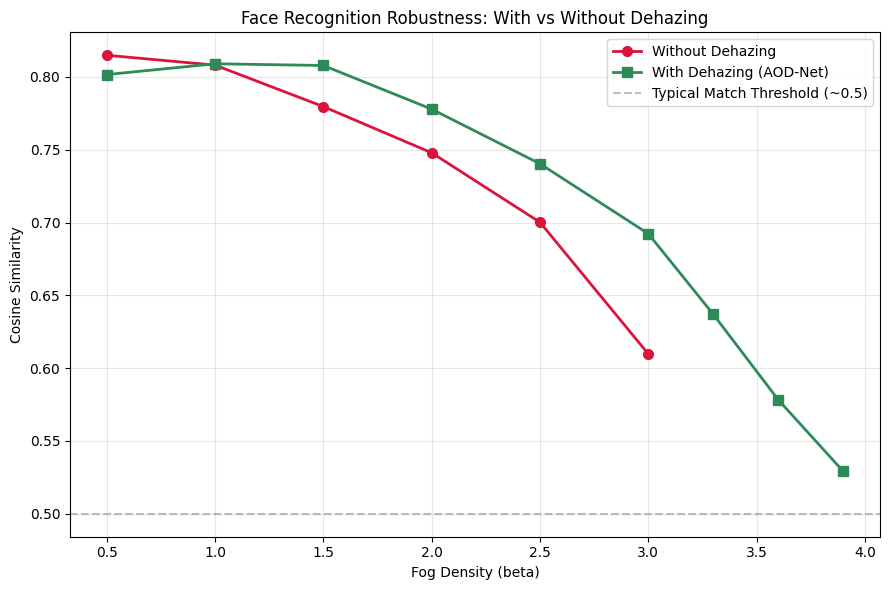

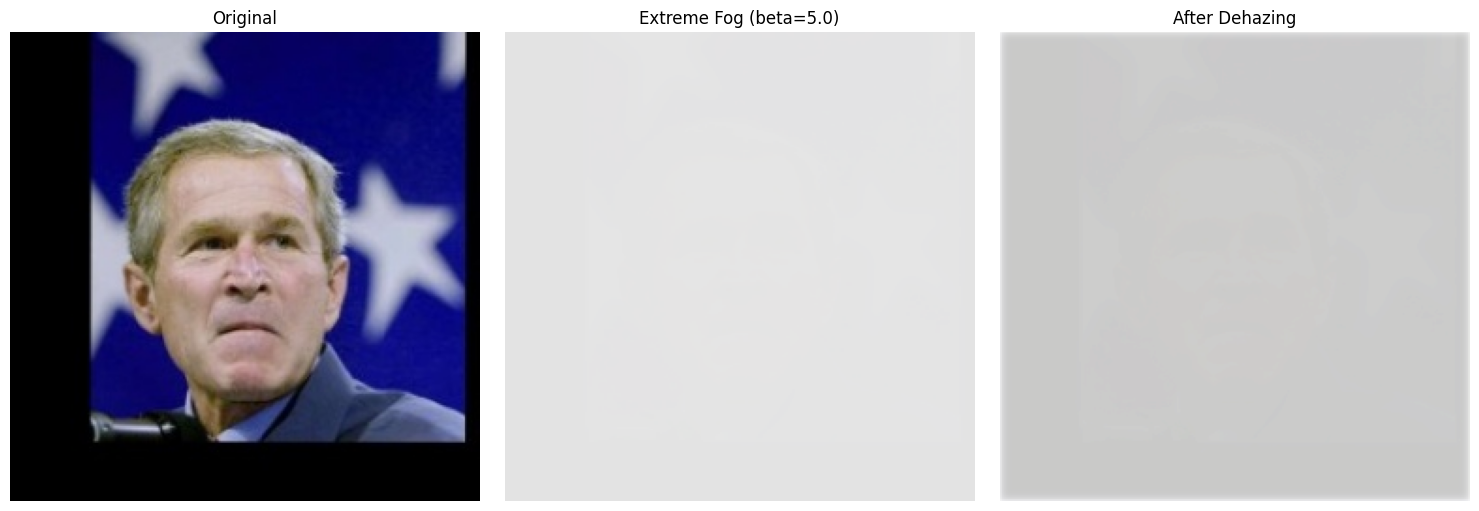

Saved robustness plot + extreme fog example ✅


In [12]:
# ============================================
# CELL 12: Plot + extreme fog visual
# ============================================
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(df_fog['beta'], df_fog['similarity_foggy'], 'o-', color='crimson', label='Without Dehazing', linewidth=2, markersize=7)
ax.plot(df_fog['beta'], df_fog['similarity_dehazed'], 's-', color='seagreen', label='With Dehazing (AOD-Net)', linewidth=2, markersize=7)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Typical Match Threshold (~0.5)')
ax.set_xlabel('Fog Density (beta)'); ax.set_ylabel('Cosine Similarity')
ax.set_title('Face Recognition Robustness: With vs Without Dehazing')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/results/fog_vs_recognition_robustness.png', dpi=150)
plt.show()

foggy_extreme = add_synthetic_fog(test_photo_path, beta=5.0, A=0.9)
foggy_tensor = torch.from_numpy(np.asarray(foggy_extreme, dtype=np.float32)/255.0).permute(2,0,1).unsqueeze(0).to(device)
with torch.no_grad():
    dehazed_tensor = model(foggy_tensor)
dehazed_extreme = tensor_to_image(dehazed_tensor)
original_pil = Image.open(test_photo_path)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(original_pil); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(foggy_extreme); axes[1].set_title('Extreme Fog (beta=5.0)'); axes[1].axis('off')
axes[2].imshow(dehazed_extreme); axes[2].set_title('After Dehazing'); axes[2].axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/results/extreme_fog_example.png', dpi=150)
plt.show()
print("Saved robustness plot + extreme fog example ✅")

In [13]:
# ============================================
# CELL 13: Build synthetic video + run FPS benchmark
# ============================================
n_frames = 40
photo_cycle = (bush_photos * ((n_frames // len(bush_photos)) + 1))[:n_frames]
beta_schedule = np.linspace(0.0, 3.5, n_frames)
frame_size = (250, 250)
video_path = '/kaggle/working/synthetic_fog_video.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(video_path, fourcc, 10, frame_size)

for photo, beta in zip(photo_cycle, beta_schedule):
    img_path = os.path.join(bush_folder, photo)
    foggy_pil = add_synthetic_fog(img_path, beta=beta, A=0.9).resize(frame_size)
    frame_bgr = cv2.cvtColor(np.array(foggy_pil), cv2.COLOR_RGB2BGR)
    out.write(frame_bgr)
out.release()

cap = cv2.VideoCapture(video_path)
results_video = []
frame_idx = 0
total_time_detect_only = 0
total_time_dehaze_detect = 0

while True:
    ret, frame_bgr = cap.read()
    if not ret:
        break
    beta_current = beta_schedule[frame_idx] if frame_idx < len(beta_schedule) else None

    t0 = time.time()
    faces_raw = face_app.get(frame_bgr)
    t1 = time.time()
    total_time_detect_only += (t1 - t0)

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    frame_np = frame_rgb.astype(np.float32) / 255.0
    frame_tensor = torch.from_numpy(frame_np).permute(2, 0, 1).unsqueeze(0).to(device)

    t2 = time.time()
    with torch.no_grad():
        dehazed_tensor = model(frame_tensor)
    dehazed_np = tensor_to_image(dehazed_tensor)
    dehazed_bgr = cv2.cvtColor((dehazed_np * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
    faces_dehazed = face_app.get(dehazed_bgr)
    t3 = time.time()
    total_time_dehaze_detect += (t3 - t2)

    results_video.append({'frame': frame_idx, 'beta': beta_current,
                           'faces_raw': len(faces_raw), 'faces_dehazed': len(faces_dehazed)})
    frame_idx += 1

cap.release()
df_video = pd.DataFrame(results_video)
df_video.to_csv('/kaggle/working/results/video_pipeline_results_optimized.csv', index=False)

fps_detect_only = frame_idx / total_time_detect_only
fps_dehaze_detect = frame_idx / total_time_dehaze_detect
print(f"Detection Only FPS: {fps_detect_only:.2f} | Dehaze+Detect FPS: {fps_dehaze_detect:.2f}")
print("Saved video_pipeline_results_optimized.csv ✅")
print("\nALL RESULTS FILES:", os.listdir('/kaggle/working/results'))

Detection Only FPS: 2.35 | Dehaze+Detect FPS: 2.19
Saved video_pipeline_results_optimized.csv ✅

ALL RESULTS FILES: ['extreme_fog_example.png', 'worst_case.png', 'video_pipeline_results_optimized.csv', 'fog_vs_recognition_robustness.png', 'aodnet_baseline_results.csv', 'fog_recognition_experiment.csv', 'best_case.png', 'fog_density_correlation.png']


In [14]:
# ============================================
# CELL A: Setup — LFW extraction + top identities
# ============================================
import os
import tarfile
import numpy as np

lfw_input_folder = '/kaggle/input/datasets/atulanandjha/lfwpeople'
tgz_path = os.path.join(lfw_input_folder, 'lfw-funneled.tgz')
extract_root = '/kaggle/working/lfw_extracted'
os.makedirs(extract_root, exist_ok=True)
if not os.path.exists(os.path.join(extract_root, 'lfw_funneled')):
    with tarfile.open(tgz_path, 'r:gz') as tar:
        tar.extractall(path=extract_root)
extract_path = os.path.join(extract_root, 'lfw_funneled')

people = [p for p in os.listdir(extract_path) if os.path.isdir(os.path.join(extract_path, p))]
photo_counts = {p: len(os.listdir(os.path.join(extract_path, p))) for p in people}
top_identities = sorted(photo_counts.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 identities selected for training:")
for name, count in top_identities:
    print(f"  {name}: {count} photos")

Top 10 identities selected for training:
  George_W_Bush: 530 photos
  Colin_Powell: 236 photos
  Tony_Blair: 144 photos
  Donald_Rumsfeld: 121 photos
  Gerhard_Schroeder: 109 photos
  Ariel_Sharon: 77 photos
  Hugo_Chavez: 71 photos
  Junichiro_Koizumi: 60 photos
  Jean_Chretien: 55 photos
  John_Ashcroft: 53 photos


In [16]:
# ============================================
# CELL B: Build train/val photo list (multiple identities)
# ============================================
train_photo_paths = []
val_photo_paths = []

for name, count in top_identities:
    person_folder = os.path.join(extract_path, name)
    photos = sorted(os.listdir(person_folder))
    photo_paths = [os.path.join(person_folder, p) for p in photos]
    
    # 80/20 split per identity
    split_idx = max(1, int(len(photo_paths) * 0.8))
    train_photo_paths.extend(photo_paths[:split_idx])
    val_photo_paths.extend(photo_paths[split_idx:])

print(f"Total training images: {len(train_photo_paths)}")
print(f"Total validation images: {len(val_photo_paths)}")

Total training images: 1161
Total validation images: 295


In [22]:
!pip install --upgrade torchvision -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 69.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 3.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 10.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 9.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 28.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 9.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 1.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 2.7 MB/s eta 0:00:000:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 6.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

In [3]:
# ============================================
# CELL D-1: InceptionResnetV1 architecture (standalone, no package conflicts)
# ============================================
import torch
import torch.nn as nn
from torch.nn import functional as F

class BasicConv2d(nn.Module):
    def __init__(self, in_planes, out_planes, kernel_size, stride, padding=0):
        super().__init__()
        self.conv = nn.Conv2d(in_planes, out_planes, kernel_size=kernel_size, stride=stride, padding=padding, bias=False)
        self.bn = nn.BatchNorm2d(out_planes, eps=0.001, momentum=0.1, affine=True)
        self.relu = nn.ReLU(inplace=False)
    def forward(self, x):
        x = self.conv(x); x = self.bn(x); x = self.relu(x)
        return x

class Block35(nn.Module):
    def __init__(self, scale=1.0):
        super().__init__()
        self.scale = scale
        self.branch0 = BasicConv2d(256, 32, kernel_size=1, stride=1)
        self.branch1 = nn.Sequential(BasicConv2d(256, 32, kernel_size=1, stride=1), BasicConv2d(32, 32, kernel_size=3, stride=1, padding=1))
        self.branch2 = nn.Sequential(BasicConv2d(256, 32, kernel_size=1, stride=1), BasicConv2d(32, 32, kernel_size=3, stride=1, padding=1), BasicConv2d(32, 32, kernel_size=3, stride=1, padding=1))
        self.conv2d = nn.Conv2d(96, 256, kernel_size=1, stride=1)
        self.relu = nn.ReLU(inplace=False)
    def forward(self, x):
        x0 = self.branch0(x); x1 = self.branch1(x); x2 = self.branch2(x)
        out = torch.cat((x0, x1, x2), 1); out = self.conv2d(out)
        out = out * self.scale + x; out = self.relu(out)
        return out

class Block17(nn.Module):
    def __init__(self, scale=1.0):
        super().__init__()
        self.scale = scale
        self.branch0 = BasicConv2d(896, 128, kernel_size=1, stride=1)
        self.branch1 = nn.Sequential(BasicConv2d(896, 128, kernel_size=1, stride=1), BasicConv2d(128, 128, kernel_size=(1,7), stride=1, padding=(0,3)), BasicConv2d(128, 128, kernel_size=(7,1), stride=1, padding=(3,0)))
        self.conv2d = nn.Conv2d(256, 896, kernel_size=1, stride=1)
        self.relu = nn.ReLU(inplace=False)
    def forward(self, x):
        x0 = self.branch0(x); x1 = self.branch1(x)
        out = torch.cat((x0, x1), 1); out = self.conv2d(out)
        out = out * self.scale + x; out = self.relu(out)
        return out

class Block8(nn.Module):
    def __init__(self, scale=1.0, noReLU=False):
        super().__init__()
        self.scale = scale; self.noReLU = noReLU
        self.branch0 = BasicConv2d(1792, 192, kernel_size=1, stride=1)
        self.branch1 = nn.Sequential(BasicConv2d(1792, 192, kernel_size=1, stride=1), BasicConv2d(192, 192, kernel_size=(1,3), stride=1, padding=(0,1)), BasicConv2d(192, 192, kernel_size=(3,1), stride=1, padding=(1,0)))
        self.conv2d = nn.Conv2d(384, 1792, kernel_size=1, stride=1)
        if not self.noReLU:
            self.relu = nn.ReLU(inplace=False)
    def forward(self, x):
        x0 = self.branch0(x); x1 = self.branch1(x)
        out = torch.cat((x0, x1), 1); out = self.conv2d(out)
        out = out * self.scale + x
        if not self.noReLU:
            out = self.relu(out)
        return out

class Mixed_6a(nn.Module):
    def __init__(self):
        super().__init__()
        self.branch0 = BasicConv2d(256, 384, kernel_size=3, stride=2)
        self.branch1 = nn.Sequential(BasicConv2d(256, 192, kernel_size=1, stride=1), BasicConv2d(192, 192, kernel_size=3, stride=1, padding=1), BasicConv2d(192, 256, kernel_size=3, stride=2))
        self.branch2 = nn.MaxPool2d(3, stride=2)
    def forward(self, x):
        x0 = self.branch0(x); x1 = self.branch1(x); x2 = self.branch2(x)
        return torch.cat((x0, x1, x2), 1)

class Mixed_7a(nn.Module):
    def __init__(self):
        super().__init__()
        self.branch0 = nn.Sequential(BasicConv2d(896, 256, kernel_size=1, stride=1), BasicConv2d(256, 384, kernel_size=3, stride=2))
        self.branch1 = nn.Sequential(BasicConv2d(896, 256, kernel_size=1, stride=1), BasicConv2d(256, 256, kernel_size=3, stride=2))
        self.branch2 = nn.Sequential(BasicConv2d(896, 256, kernel_size=1, stride=1), BasicConv2d(256, 256, kernel_size=3, stride=1, padding=1), BasicConv2d(256, 256, kernel_size=3, stride=2))
        self.branch3 = nn.MaxPool2d(3, stride=2)
    def forward(self, x):
        x0 = self.branch0(x); x1 = self.branch1(x); x2 = self.branch2(x); x3 = self.branch3(x)
        return torch.cat((x0, x1, x2, x3), 1)

class InceptionResnetV1(nn.Module):
    def __init__(self, pretrained=None, classify=False, num_classes=None, dropout_prob=0.6, device=None):
        super().__init__()
        self.classify = classify
        self.num_classes = num_classes
        self.conv2d_1a = BasicConv2d(3, 32, kernel_size=3, stride=2)
        self.conv2d_2a = BasicConv2d(32, 32, kernel_size=3, stride=1)
        self.conv2d_2b = BasicConv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.maxpool_3a = nn.MaxPool2d(3, stride=2)
        self.conv2d_3b = BasicConv2d(64, 80, kernel_size=1, stride=1)
        self.conv2d_4a = BasicConv2d(80, 192, kernel_size=3, stride=1)
        self.conv2d_4b = BasicConv2d(192, 256, kernel_size=3, stride=2)
        self.repeat_1 = nn.Sequential(*[Block35(scale=0.17) for _ in range(5)])
        self.mixed_6a = Mixed_6a()
        self.repeat_2 = nn.Sequential(*[Block17(scale=0.10) for _ in range(10)])
        self.mixed_7a = Mixed_7a()
        self.repeat_3 = nn.Sequential(*[Block8(scale=0.20) for _ in range(5)])
        self.block8 = Block8(noReLU=True)
        self.avgpool_1a = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout_prob)
        self.last_linear = nn.Linear(1792, 512, bias=False)
        self.last_bn = nn.BatchNorm1d(512, eps=0.001, momentum=0.1, affine=True)

    def forward(self, x):
        x = self.conv2d_1a(x); x = self.conv2d_2a(x); x = self.conv2d_2b(x)
        x = self.maxpool_3a(x); x = self.conv2d_3b(x); x = self.conv2d_4a(x); x = self.conv2d_4b(x)
        x = self.repeat_1(x); x = self.mixed_6a(x); x = self.repeat_2(x)
        x = self.mixed_7a(x); x = self.repeat_3(x); x = self.block8(x)
        x = self.avgpool_1a(x); x = self.dropout(x)
        x = self.last_linear(x.view(x.shape[0], -1)); x = self.last_bn(x)
        if self.classify:
            x = self.logits(x)
        else:
            x = F.normalize(x, p=2, dim=1)
        return x

print("InceptionResnetV1 architecture defined ✅")

InceptionResnetV1 architecture defined ✅


In [6]:
# ============================================
# CELL D-2: Download pretrained weights + load
# ============================================
import os
import urllib.request

weight_url = "https://github.com/timesler/facenet-pytorch/releases/download/v2.2.9/20180402-114759-vggface2.pt"
facenet_weight_path = "/kaggle/working/weights/facenet_vggface2.pt"
os.makedirs('/kaggle/working/weights', exist_ok=True)

if not os.path.exists(facenet_weight_path):
    urllib.request.urlretrieve(weight_url, facenet_weight_path)

print("Downloaded:", os.path.exists(facenet_weight_path), "| Size (MB):", os.path.getsize(facenet_weight_path)/1e6)

Downloaded: True | Size (MB): 111.898327


In [7]:
# ============================================
# CELL D-3: Instantiate + load weights + freeze
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

facenet = InceptionResnetV1(pretrained=None, classify=False)
facenet.logits = nn.Linear(512, 8631)  # matches state_dict shape (unused in forward since classify=False)

state_dict = torch.load(facenet_weight_path, map_location=device)
facenet.load_state_dict(state_dict, strict=False)

facenet = facenet.eval().to(device)
for param in facenet.parameters():
    param.requires_grad = False

# Quick sanity test
test_input = torch.randn(2, 3, 160, 160).to(device)
with torch.no_grad():
    test_output = facenet(test_input)
print("FaceNet loaded ✅ | Output shape:", test_output.shape, "| device:", device)

FaceNet loaded ✅ | Output shape: torch.Size([2, 512]) | device: cuda


In [8]:
# ============================================
# CELL F: AODNet architecture + load pretrained weights
# ============================================
class AODNet(nn.Module):
    def __init__(self):
        super(AODNet, self).__init__()
        self.relu = nn.ReLU(inplace=True)
        self.e_conv1 = nn.Conv2d(3, 3, 1, 1, 0)
        self.e_conv2 = nn.Conv2d(3, 3, 3, 1, 1)
        self.e_conv3 = nn.Conv2d(6, 3, 5, 1, 2)
        self.e_conv4 = nn.Conv2d(6, 3, 7, 1, 3)
        self.e_conv5 = nn.Conv2d(12, 3, 3, 1, 1)

    def forward(self, x):
        x1 = self.relu(self.e_conv1(x))
        x2 = self.relu(self.e_conv2(x1))
        cat1 = torch.cat((x1, x2), 1)
        x3 = self.relu(self.e_conv3(cat1))
        cat2 = torch.cat((x2, x3), 1)
        x4 = self.relu(self.e_conv4(cat2))
        cat3 = torch.cat((x1, x2, x3, x4), 1)
        k = self.relu(self.e_conv5(cat3))
        output = k * x - k + 1
        return self.relu(output)

weight_path = "/kaggle/working/weights/aod_net.pth"
if not os.path.exists(weight_path):
    weight_url = "https://raw.githubusercontent.com/MayankSingal/PyTorch-Image-Dehazing/master/snapshots/dehazer.pth"
    urllib.request.urlretrieve(weight_url, weight_path)

model = AODNet().to(device)
model.load_state_dict(torch.load(weight_path, map_location=device))

print("AOD-Net (pretrained baseline) loaded ✅")

AOD-Net (pretrained baseline) loaded ✅


In [9]:
# ============================================
# CELL G: LFW multi-identity training pairs (rebuild after restart)
# ============================================
import tarfile

lfw_input_folder = '/kaggle/input/datasets/atulanandjha/lfwpeople'
tgz_path = os.path.join(lfw_input_folder, 'lfw-funneled.tgz')
extract_root = '/kaggle/working/lfw_extracted'
os.makedirs(extract_root, exist_ok=True)
if not os.path.exists(os.path.join(extract_root, 'lfw_funneled')):
    with tarfile.open(tgz_path, 'r:gz') as tar:
        tar.extractall(path=extract_root)
extract_path = os.path.join(extract_root, 'lfw_funneled')

people = [p for p in os.listdir(extract_path) if os.path.isdir(os.path.join(extract_path, p))]
photo_counts = {p: len(os.listdir(os.path.join(extract_path, p))) for p in people}
top_identities = sorted(photo_counts.items(), key=lambda x: x[1], reverse=True)[:10]

train_photo_paths, val_photo_paths = [], []
for name, count in top_identities:
    person_folder = os.path.join(extract_path, name)
    photos = sorted(os.listdir(person_folder))
    photo_paths = [os.path.join(person_folder, p) for p in photos]
    split_idx = max(1, int(len(photo_paths) * 0.8))
    train_photo_paths.extend(photo_paths[:split_idx])
    val_photo_paths.extend(photo_paths[split_idx:])

print(f"Train: {len(train_photo_paths)} | Val: {len(val_photo_paths)}")

/tmp/ipykernel_59/2811579791.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_root)


Train: 1161 | Val: 295


In [10]:
# ============================================
# CELL H: PyTorch Dataset — on-the-fly fog generation
# ============================================
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import random

class FogFaceDataset(Dataset):
    def __init__(self, photo_paths, img_size=128, beta_range=(0.5, 3.0)):
        self.photo_paths = photo_paths
        self.img_size = img_size
        self.beta_range = beta_range

    def __len__(self):
        return len(self.photo_paths)

    def __getitem__(self, idx):
        img_path = self.photo_paths[idx]
        clear_pil = Image.open(img_path).convert('RGB').resize((self.img_size, self.img_size))
        clear_np = np.asarray(clear_pil, dtype=np.float32) / 255.0

        beta = random.uniform(*self.beta_range)
        A = 0.9
        t = np.exp(-beta)
        hazy_np = clear_np * t + A * (1 - t)
        hazy_np = np.clip(hazy_np, 0, 1)

        clear_tensor = torch.from_numpy(clear_np).permute(2, 0, 1)
        hazy_tensor = torch.from_numpy(hazy_np.astype(np.float32)).permute(2, 0, 1)

        return hazy_tensor, clear_tensor

train_dataset = FogFaceDataset(train_photo_paths, img_size=128)
val_dataset = FogFaceDataset(val_photo_paths, img_size=128)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 73 | Val batches: 19


In [11]:
# ============================================
# CELL I: Recognition-aware loss function
# ============================================
import torch.nn.functional as Fn

def recognition_aware_loss(dehazed, clear, facenet_model, lambda_rec=0.5):
    recon_loss = Fn.mse_loss(dehazed, clear)

    dehazed_r = Fn.interpolate(dehazed, size=(160, 160), mode='bilinear', align_corners=False)
    clear_r = Fn.interpolate(clear, size=(160, 160), mode='bilinear', align_corners=False)
    dehazed_norm = (dehazed_r - 0.5) / 0.5
    clear_norm = (clear_r - 0.5) / 0.5

    emb_dehazed = facenet_model(dehazed_norm)
    emb_clear = facenet_model(clear_norm)

    cos_sim = Fn.cosine_similarity(emb_dehazed, emb_clear, dim=1)
    recognition_loss = (1 - cos_sim).mean()

    total = recon_loss + lambda_rec * recognition_loss
    return total, recon_loss.item(), recognition_loss.item()

print("Loss function ready ✅")

Loss function ready ✅


In [12]:
# ============================================
# CELL J: Training loop
# ============================================
import torch.optim as optim
import copy

# Fresh copy of pretrained AOD-Net — hum isay fine-tune karenge
# (original 'model' ko untouched rakhte hain baseline comparison ke liye)
model_finetuned = AODNet().to(device)
model_finetuned.load_state_dict(torch.load(weight_path, map_location=device))
model_finetuned.train()

optimizer = optim.Adam(model_finetuned.parameters(), lr=1e-4)
num_epochs = 10
lambda_rec = 0.5

history = {'epoch': [], 'train_loss': [], 'train_recon': [], 'train_recog': [], 'val_loss': []}

for epoch in range(num_epochs):
    # ---- Training ----
    model_finetuned.train()
    epoch_loss, epoch_recon, epoch_recog = 0, 0, 0

    for hazy, clear in train_loader:
        hazy, clear = hazy.to(device), clear.to(device)

        optimizer.zero_grad()
        dehazed = model_finetuned(hazy)
        loss, recon_l, recog_l = recognition_aware_loss(dehazed, clear, facenet, lambda_rec)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_recon += recon_l
        epoch_recog += recog_l

    avg_train_loss = epoch_loss / len(train_loader)
    avg_recon = epoch_recon / len(train_loader)
    avg_recog = epoch_recog / len(train_loader)

    # ---- Validation ----
    model_finetuned.eval()
    val_loss = 0
    with torch.no_grad():
        for hazy, clear in val_loader:
            hazy, clear = hazy.to(device), clear.to(device)
            dehazed = model_finetuned(hazy)
            loss, _, _ = recognition_aware_loss(dehazed, clear, facenet, lambda_rec)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)

    history['epoch'].append(epoch + 1)
    history['train_loss'].append(avg_train_loss)
    history['train_recon'].append(avg_recon)
    history['train_recog'].append(avg_recog)
    history['val_loss'].append(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} (recon: {avg_recon:.4f}, recog: {avg_recog:.4f}) | Val Loss: {avg_val_loss:.4f}")

# Save fine-tuned model
finetuned_path = '/kaggle/working/weights/aod_net_finetuned.pth'
torch.save(model_finetuned.state_dict(), finetuned_path)
print(f"\nFine-tuned model saved ✅ → {finetuned_path}")

Epoch 1/10 | Train Loss: 0.1541 (recon: 0.0742, recog: 0.1598) | Val Loss: 0.1154
Epoch 2/10 | Train Loss: 0.1150 (recon: 0.0578, recog: 0.1143) | Val Loss: 0.1091
Epoch 3/10 | Train Loss: 0.1180 (recon: 0.0588, recog: 0.1183) | Val Loss: 0.1210
Epoch 4/10 | Train Loss: 0.1135 (recon: 0.0575, recog: 0.1120) | Val Loss: 0.1316
Epoch 5/10 | Train Loss: 0.1161 (recon: 0.0579, recog: 0.1165) | Val Loss: 0.1221
Epoch 6/10 | Train Loss: 0.1176 (recon: 0.0584, recog: 0.1184) | Val Loss: 0.1161
Epoch 7/10 | Train Loss: 0.1193 (recon: 0.0587, recog: 0.1212) | Val Loss: 0.1139
Epoch 8/10 | Train Loss: 0.1164 (recon: 0.0590, recog: 0.1147) | Val Loss: 0.1142
Epoch 9/10 | Train Loss: 0.1154 (recon: 0.0573, recog: 0.1162) | Val Loss: 0.1144
Epoch 10/10 | Train Loss: 0.1147 (recon: 0.0566, recog: 0.1162) | Val Loss: 0.1201

Fine-tuned model saved ✅ → /kaggle/working/weights/aod_net_finetuned.pth


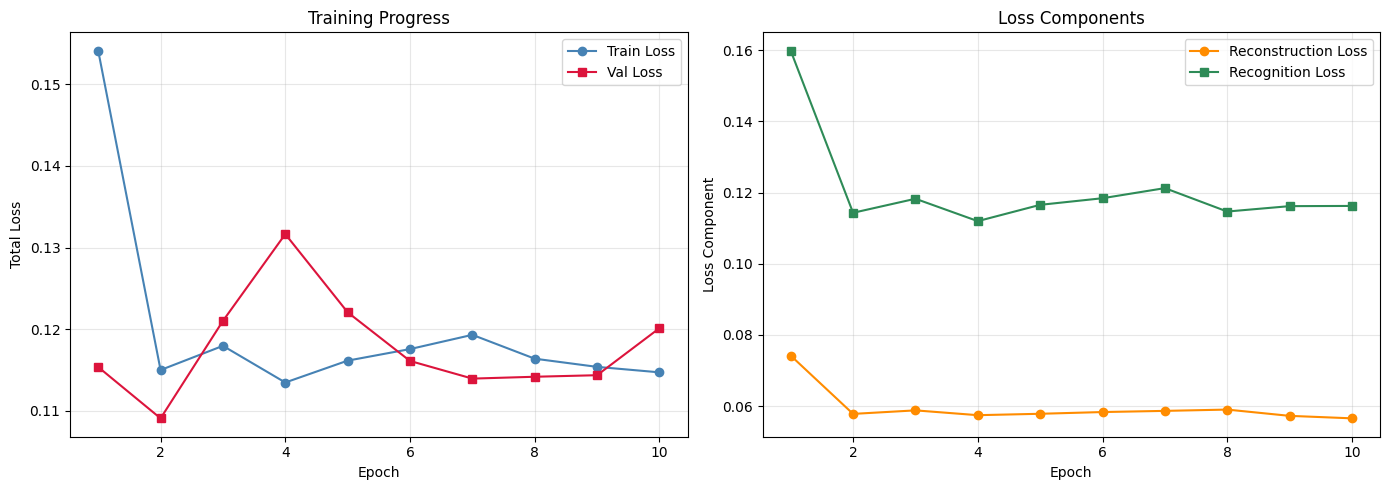

In [14]:
# ============================================
# CELL K: Training curves
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['epoch'], history['train_loss'], 'o-', label='Train Loss', color='steelblue')
axes[0].plot(history['epoch'], history['val_loss'], 's-', label='Val Loss', color='crimson')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Total Loss')
axes[0].set_title('Training Progress'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['epoch'], history['train_recon'], 'o-', label='Reconstruction Loss', color='darkorange')
axes[1].plot(history['epoch'], history['train_recog'], 's-', label='Recognition Loss', color='seagreen')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss Component')
axes[1].set_title('Loss Components'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

In [17]:
# ============================================
# CELL K-1: Install insightface (no LD_LIBRARY_PATH manipulation this time)
# ============================================
!pip install insightface onnxruntime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 4.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 54.0 MB/s eta 0:00:0000:0100:01


In [18]:
# CELL K-2: Re-verify torch still works after restart
import torch
print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

Torch: 2.10.0+cu128 | CUDA: True


In [19]:
# CELL K-3: Reload both models (pretrained + finetuned) — no need to retrain
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = AODNet().to(device)
model.load_state_dict(torch.load('/kaggle/working/weights/aod_net.pth', map_location=device))
model.eval()

model_finetuned = AODNet().to(device)
model_finetuned.load_state_dict(torch.load('/kaggle/working/weights/aod_net_finetuned.pth', map_location=device))
model_finetuned.eval()

print("Both models loaded ✅")

Both models loaded ✅


In [20]:
# CELL K-4: Load face_app (CPU fallback is fine here)
from insightface.app import FaceAnalysis

face_app = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'])
face_app.prepare(ctx_id=-1, det_size=(320, 320))

print("Face app ready ✅")

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 75091.55KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (320, 320)
Face app rea

In [21]:
# CELL K-5: Enrollment embedding (need this again — fresh session)
def get_embedding(img_path):
    img_bgr = cv2.imread(img_path)
    faces = face_app.get(img_bgr)
    return faces[0].embedding if len(faces) > 0 else None

def cosine_similarity(emb1, emb2):
    return np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))

bush_folder = os.path.join(extract_path, 'George_W_Bush')
bush_photos = sorted(os.listdir(bush_folder))
enrollment_path = os.path.join(bush_folder, bush_photos[0])
test_photo_path = os.path.join(bush_folder, bush_photos[1])

enrollment_embedding = get_embedding(enrollment_path)
print("Enrollment ready ✅")

Enrollment ready ✅


In [23]:
# ============================================
# CELL K-2.5: Missing helper functions
# ============================================
def add_synthetic_fog(img_path, beta=1.5, A=0.9):
    img = Image.open(img_path).convert('RGB')
    img_np = np.asarray(img, dtype=np.float32) / 255.0
    t = np.exp(-beta)
    foggy = img_np * t + A * (1 - t)
    foggy = np.clip(foggy, 0, 1)
    return Image.fromarray((foggy * 255).astype(np.uint8))

def tensor_to_image(tensor):
    img = tensor.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    return np.clip(img, 0, 1)

print("Helpers ready ✅")

Helpers ready ✅


In [24]:
# ============================================
# CELL L: THE KEY COMPARISON — Pretrained vs Fine-tuned
# Operational range test (same experiment as before, both models)
# ============================================
def run_operational_range_test(dehazing_model, enrollment_embedding_arcface, test_photo_path, beta_values):
    """Uses insightface's ArcFace for evaluation consistency with earlier experiments"""
    results = []
    for beta in beta_values:
        foggy_pil = add_synthetic_fog(test_photo_path, beta=beta, A=0.9)
        foggy_np = np.asarray(foggy_pil, dtype=np.float32) / 255.0
        foggy_tensor = torch.from_numpy(foggy_np).permute(2, 0, 1).unsqueeze(0).to(device)

        with torch.no_grad():
            dehazed_tensor = dehazing_model(foggy_tensor)
        dehazed_np = tensor_to_image(dehazed_tensor)
        dehazed_pil = Image.fromarray((dehazed_np * 255).astype(np.uint8))

        img_bgr = cv2.cvtColor(np.array(dehazed_pil), cv2.COLOR_RGB2BGR)
        faces = face_app.get(img_bgr)
        n_faces = len(faces)
        sim = cosine_similarity(enrollment_embedding_arcface, faces[0].embedding) if n_faces > 0 else None

        results.append({'beta': beta, 'faces_detected': n_faces, 'similarity': sim})
    return pd.DataFrame(results)

beta_values_compare = [2.5, 2.8, 3.0, 3.3, 3.6, 3.9, 4.2]

print("Testing PRETRAINED AOD-Net...")
df_pretrained = run_operational_range_test(model, enrollment_embedding, test_photo_path, beta_values_compare)

print("\nTesting FINE-TUNED AOD-Net...")
df_finetuned = run_operational_range_test(model_finetuned, enrollment_embedding, test_photo_path, beta_values_compare)

print("\n--- PRETRAINED ---")
print(df_pretrained.to_string(index=False))
print("\n--- FINE-TUNED ---")
print(df_finetuned.to_string(index=False))

Testing PRETRAINED AOD-Net...

Testing FINE-TUNED AOD-Net...

--- PRETRAINED ---
 beta  faces_detected  similarity
  2.5               1    0.740366
  2.8               1    0.724283
  3.0               1    0.692366
  3.3               1    0.637021
  3.6               1    0.578331
  3.9               1    0.529215
  4.2               0         NaN

--- FINE-TUNED ---
 beta  faces_detected  similarity
  2.5               1    0.787941
  2.8               1    0.765220
  3.0               1    0.746172
  3.3               1    0.684330
  3.6               1    0.657840
  3.9               1    0.683637
  4.2               1    0.561235


In [28]:
# ============================================
# CELL M-FIX: Summary stats (properly aligned by beta)
# ============================================
merged = pd.merge(df_pretrained, df_finetuned, on='beta', suffixes=('_pretrained', '_finetuned'))
merged_valid = merged.dropna(subset=['similarity_pretrained', 'similarity_finetuned'])

merged_valid = merged_valid.copy()
merged_valid['improvement_pct'] = (
    (merged_valid['similarity_finetuned'] - merged_valid['similarity_pretrained']) 
    / merged_valid['similarity_pretrained'] * 100
)

print(merged_valid[['beta', 'similarity_pretrained', 'similarity_finetuned', 'improvement_pct']].to_string(index=False))

print(f"\nAverage similarity improvement (where both detected): {merged_valid['improvement_pct'].mean():.1f}%")
print(f"Pretrained max operational beta: {df_pretrained[df_pretrained['faces_detected']>0]['beta'].max()}")
print(f"Fine-tuned max operational beta: {df_finetuned[df_finetuned['faces_detected']>0]['beta'].max()}")

merged.to_csv('/kaggle/working/pretrained_vs_finetuned_merged.csv', index=False)

 beta  similarity_pretrained  similarity_finetuned  improvement_pct
  2.5               0.740366              0.787941         6.425833
  2.8               0.724283              0.765220         5.652065
  3.0               0.692366              0.746172         7.771199
  3.3               0.637021              0.684330         7.426604
  3.6               0.578331              0.657840        13.747928
  3.9               0.529215              0.683637        29.179418

Average similarity improvement (where both detected): 11.7%
Pretrained max operational beta: 3.9
Fine-tuned max operational beta: 4.2
